# Setup and Import

In [72]:
pip install ydata_profiling

Note: you may need to restart the kernel to use updated packages.


In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
#from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle
import warnings
warnings.filterwarnings('ignore')

In [74]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [75]:
df=pd.read_csv("loan_approved.csv")

In [76]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# 2.Imputing the null values :

In [77]:
df.isnull().sum()

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [78]:
df['Gender'].value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

In [79]:
df.loc[df['Gender'].isnull(),'Gender']='Male'  #we have imput the null values with the Male

In [80]:
df.Gender.isnull().sum()

np.int64(0)

In [81]:
df.loc[df['Credit_History'].isnull(),'Credit_History']=0.0 # We have imputed the null values with the 0 

In [82]:
df.Credit_History.isnull().sum()

np.int64(0)

In [83]:
df.loc[df['LoanAmount'].isnull(),'LoanAmount']=df['LoanAmount'].median()

In [84]:
df.LoanAmount.isnull().sum()

np.int64(0)

In [85]:
df['Married'].value_counts()

Married
Yes    398
No     213
Name: count, dtype: int64

In [86]:
df.loc[df['Married'].isnull(),'Married']="Yes"

In [87]:
df.loc[df['Self_Employed'].isnull(),'Self_Employed']='No'

In [88]:
df.loc[df['Loan_Amount_Term'].isnull(),'Loan_Amount_Term']=360.0

In [89]:
df.loc[df['Dependents'].isnull(),'Dependents']='0'

In [90]:
df.isnull().sum()

Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status (Approved)    0
dtype: int64

# 3.Visualizing the outliers

<Axes: xlabel='LoanAmount'>

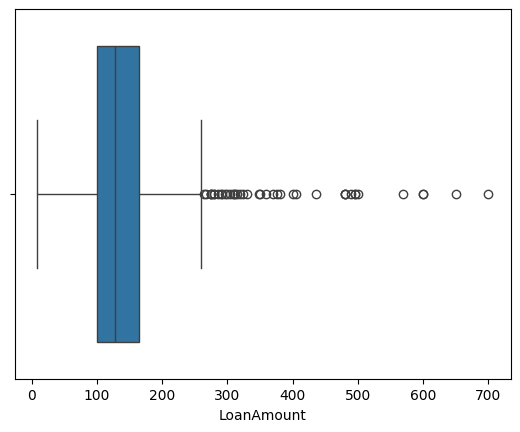

In [91]:
sns.boxplot(x=df.LoanAmount , orient='h')

<Axes: xlabel='ApplicantIncome'>

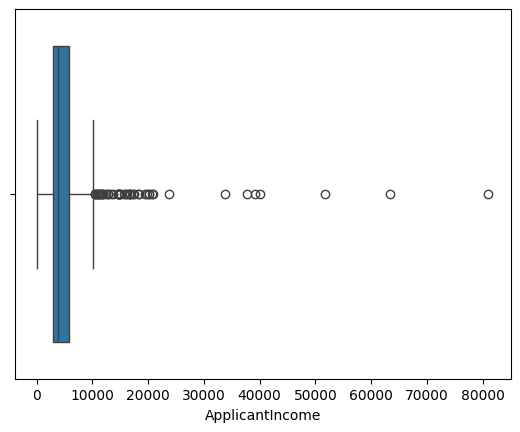

In [92]:
sns.boxplot(x=df.ApplicantIncome, orient='h')

In [93]:
from scipy.stats.mstats import winsorize
# specify the percentage of the data to be trimmed from both ends 
trim_percentage = 0.05
#winsorize the speccified columns
df['ApplicantIncome']=winsorize(df['ApplicantIncome'], limits=trim_percentage)

<Axes: xlabel='ApplicantIncome'>

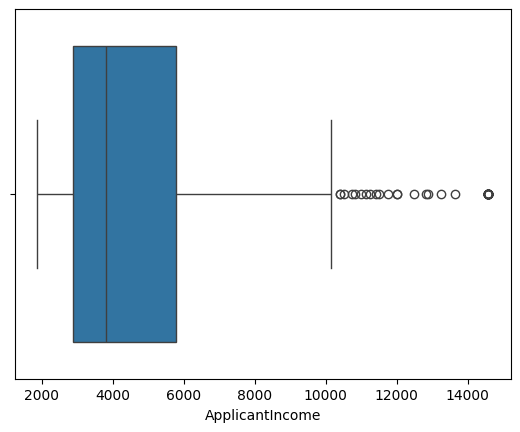

In [94]:
sns.boxplot(x=df.ApplicantIncome, orient ='h')

In [95]:
# specify the percentage of the data to be trimmed from both ends 
trim_percentage = 0.08
#winsorize the speccified columns
df['ApplicantIncome']=winsorize(df['ApplicantIncome'], limits=trim_percentage)

<Axes: xlabel='ApplicantIncome'>

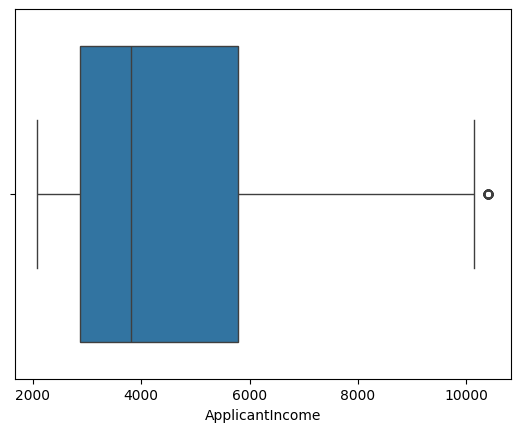

In [96]:
sns.boxplot(x=df.ApplicantIncome, orient ='h')

In [97]:
# specify the percentage of the data to be trimmed from both ends 
trim_percentage = 0.00
#winsorize the speccified columns
df['ApplicantIncome']=winsorize(df['ApplicantIncome'], limits=trim_percentage)

<Axes: xlabel='ApplicantIncome'>

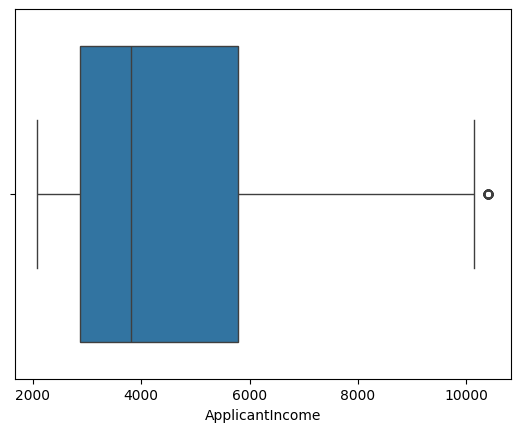

In [98]:
sns.boxplot(x=df.ApplicantIncome, orient ='h')

In [99]:
# Calcualate quartiles
Q1=df['LoanAmount'].quantile(0.25)
Q3=df['LoanAmount'].quantile(.75)

In [100]:
# Calculate IQR
IQR =Q3 - Q1
IQR

np.float64(64.5)

In [101]:
# define lower and uppwe bounds
lower_bound =Q1-1.5 *IQR
upper_bound=Q3 +1.5 *IQR

In [102]:
print(lower_bound)
print(upper_bound)

3.5
261.5


# 4.Using Label Encoding

In [103]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()  # Fit and transform the 'MatchType' column to obtain - encoded vallues
df['Married']= encoder.fit_transform(df['Married'])

# Display the result
print(df['Married'])

0      0
1      1
2      1
3      1
4      0
      ..
609    0
610    1
611    1
612    1
613    0
Name: Married, Length: 614, dtype: int64


In [104]:
education_enc= OrdinalEncoder(categories=[['Graduate', 'Not Graduate']])

In [105]:
df['Education'] = encoder.fit_transform(df[['Education']])

In [106]:
df.Education.value_counts()

Education
0    480
1    134
Name: count, dtype: int64

# Use One Hot Encoding :

In [113]:
df_encode= pd.get_dummies(df,columns=['Married'],prefix='Maried')

In [114]:
df_encoded.columns

NameError: name 'df_encoded' is not defined